# **Spacial Recommendation** (Spotify Song Prediction)

This notebook trains a GradientBooster model to predict the next song based on various features including:
- Time of day features
- Audio features (acousticness, danceability, energy, etc.)
- Contextual features (weather, playlist information)

The model will be analyzed with SHAP for interpretability.

##  Setup and Imports

In [1]:
# INFO: Runs all required dependencies for the model
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn shap xgboost

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClasssifier
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
    roc_curve
)

import shap
from joblib import dump

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# INFO: Makes Pandas show all available columns in DataFrame
pd.set_option('display.max_columns', None)

##  Load and Explore Data

In [4]:
# Loads and displays all data in DataFrame
train_df = pd.read_csv('curated.csv')
train_df.head(1)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,valence,popularity,temperature,precipitation,in_playlist,in_library,playlist_count,percentage_playlists,percentage_played,shuffle,skipped,track_id,is_morning,is_afternoon,is_evening,is_night,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11,album_id,artist_id,reason_start_enc,reason_end_enc
0,-0.713606,-0.814329,-0.674166,-0.123869,0.904744,-0.337662,1,-0.369621,-1.110379,-0.684905,-0.940824,0.458491,0.012346,1,0,1.049756,1.0,0.0051,0,0,5LtNBCM2ve0SxP0dlRVvMu,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,268,40,2,1


In [5]:
# Displays all columns datatypes
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8038 entries, 0 to 8037
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   acousticness          8038 non-null   float64
 1   danceability          8038 non-null   float64
 2   energy                8038 non-null   float64
 3   instrumentalness      8038 non-null   float64
 4   liveness              8038 non-null   float64
 5   loudness              8038 non-null   float64
 6   mode                  8038 non-null   int64  
 7   speechiness           8038 non-null   float64
 8   tempo                 8038 non-null   float64
 9   valence               8038 non-null   float64
 10  popularity            8038 non-null   float64
 11  temperature           8038 non-null   float64
 12  precipitation         8038 non-null   float64
 13  in_playlist           8038 non-null   int64  
 14  in_library            8038 non-null   int64  
 15  playlist_count       

In [6]:
# Calculates statistics for the columns
train_df.describe()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,valence,popularity,temperature,precipitation,in_playlist,in_library,playlist_count,percentage_playlists,percentage_played,shuffle,skipped,is_morning,is_afternoon,is_evening,is_night,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11,album_id,artist_id,reason_start_enc,reason_end_enc
count,8.038000e+03,8.038000e+03,8.038000e+03,8.038000e+03,8.038000e+03,8.038000e+03,8038.000000,8.038000e+03,8.038000e+03,8.038000e+03,8.038000e+03,8038.000000,8038.000000,8038.000000,8038.000000,8.038000e+03,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000,8038.000000
mean,-5.339789e-17,-2.444480e-16,-3.854979e-16,-1.765715e-16,1.050002e-16,2.145170e-16,0.440159,-1.708788e-15,-3.066304e-16,3.881499e-16,-1.115195e-16,0.481241,0.025567,0.475740,0.000249,1.677219e-14,0.475740,0.767970,0.577880,0.205151,0.087708,0.267355,0.504728,0.140209,0.114083,0.094302,0.109231,0.027494,0.090072,0.079871,0.074894,0.080368,0.116696,0.073650,0.058721,0.080617,268.847972,137.393506,4.967156,4.312516
std,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,0.496437,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,0.172520,0.096701,0.499442,0.015773,1.000062e+00,0.499442,0.381335,0.493928,0.403837,0.282888,0.442607,0.500009,0.347225,0.317932,0.292267,0.311948,0.163529,0.286303,0.271110,0.263237,0.271879,0.321077,0.261217,0.235117,0.272263,175.098150,75.072055,1.778983,1.622174
min,-1.018219e+00,-3.276436e+00,-3.553011e+00,-1.238693e-01,-1.179099e+00,-7.622255e+00,0.000000,-7.563565e-01,-2.475962e+00,-2.133132e+00,-5.306819e+00,0.000000,0.000000,0.000000,0.000000,-9.526024e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.772544e-01,-6.172023e-01,-5.841649e-01,-1.238693e-01,-6.226059e-01,-3.007084e-01,0.000000,-6.116786e-01,-8.201193e-01,-7.236800e-01,-3.295843e-01,0.354717,0.000000,0.000000,0.000000,-9.526024e-01,0.000000,0.523550,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.000000,80.000000,3.000000,5.000000
50%,-2.504057e-01,8.916681e-02,4.584488e-02,-1.238693e-01,-4.246161e-01,1.491806e-01,0.000000,-4.002261e-01,-3.950485e-02,-8.874793e-02,1.070152e-01,0.464151,0.000000,0.000000,0.000000,-9.526024e-01,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,185.000000,137.000000,6.000000,5.000000
75%,7.226372e-01,7.298272e-01,7.538559e-01,-1.237006e-01,3.461298e-01,5.900461e-01,1.000000,1.692115e-01,5.691981e-01,6.673543e-01,5.436148e-01,0.601887,0.012346,1.000000,0.000000,1.049756e+00,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,415.000000,185.000000,6.000000,5.000000
max,2.974307e+00,2.405400e+00,2.025876e+00,1.395776e+01,5.444366e+00,2.671051e+00,1.000000,7.347465e+00,2.841286e+00,2.436440e+00,2.901253e+00,1.000000,1.000000,1.000000,1.000000,1.049756e+00,1.000000,1.766000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,647.000000,287.000000,8.000000,9.000000


## Data Reprocessing & Train-Test Split

<h3 style="color: grey">Organizing Features and Target Column</h3>

In [7]:
all_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence',
    'popularity', 'temperature', 'precipitation', 'in_playlist',
    'in_library', 'playlist_count', 'percentage_playlists',
    'percentage_played', 'shuffle', 'skipped', 'is_morning',
    'is_afternoon', 'is_evening', 'is_night', 'key_0', 'key_1', 'key_2',
    'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10',
    'key_11', 'album_id', 'artist_id', 'reason_start_enc', 'reason_end_enc'
]

# Selects columns that tell specifcally about the song, and not the section/enviroment
vibe_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence', 'tempo', 'speechiness']

target_col = 'track_id'

<h3 style="color: grey">Create and Validate Clusters</h3>

In [8]:
# Creates clusters using Kmeans model, using specifc
kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE)
train_df['vibe_cluster'] = kmeans.fit_predict(train_df[vibe_features])

# Visualizes the clusters creates, and values inside each
train_df['vibe_cluster'].value_counts().sort_index()

0     622
1     836
2    1069
3      50
4     374
5     814
6     806
7    1337
8     649
9    1481
Name: vibe_cluster, dtype: int64

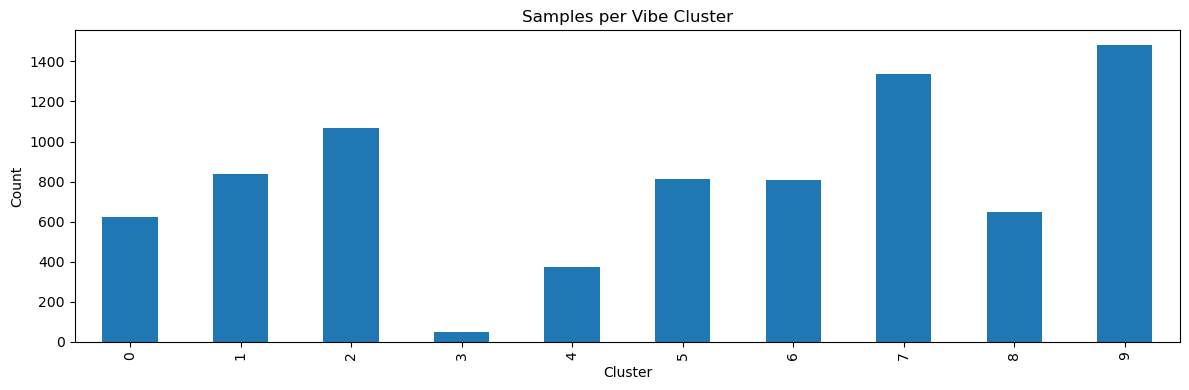

In [9]:
# Visualizes how many songs are in each cluster
plt.figure(figsize=(12, 4))
train_df['vibe_cluster'].value_counts().sort_index().plot(kind='bar')
plt.title('Samples per Vibe Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

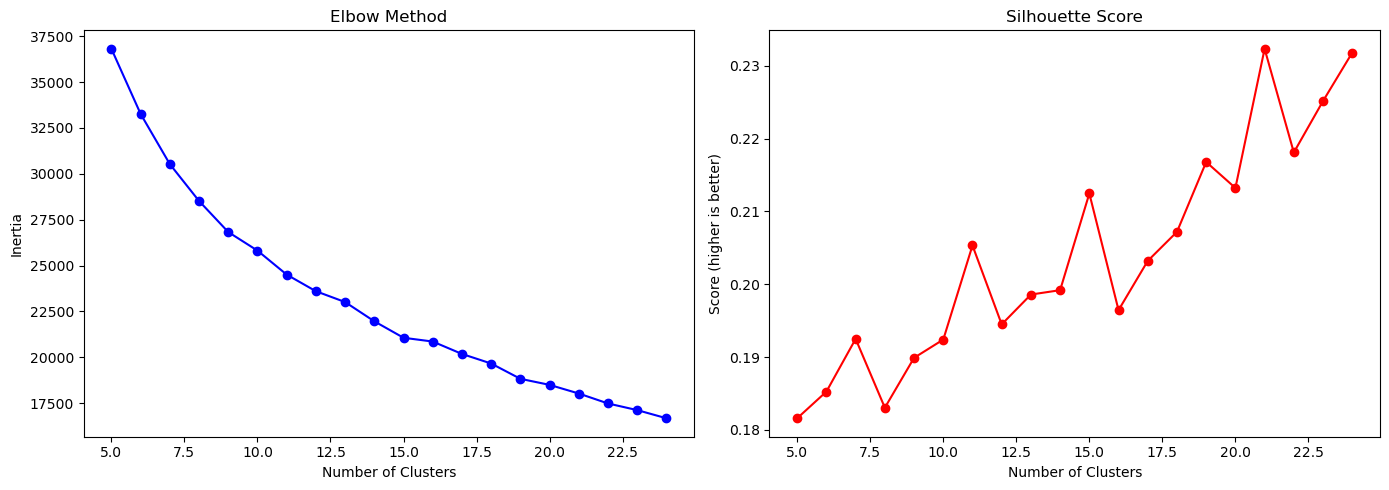

In [10]:
inertias = []
silhouettes = []
cluster_range = range(5, 25) # INFO: Different possible clusters amounts

# For each k, fit KMeans and record how tight and well-separated the clusters are
for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = km.fit_predict(train_df[vibe_features])
    inertias.append(km.inertia_) # INFO: Records how compact are the songs, the higher the better (the songs match their vibe)
    silhouettes.append(silhouette_score(train_df[vibe_features], labels)) # INFO: How well sepparate/different the clusters are

# Plot both metrics side by side to visually pick the best k
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Uses Elbow method, look for the "elbow" where inertia stops dropping
ax1.plot(cluster_range, inertias, 'bo-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')

# Uses Silhouette Score, to find n where clusters are most distinct
ax2.plot(cluster_range, silhouettes, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Score (higher is better)')      

plt.tight_layout()
plt.show()

<h3 style="color: grey">Data Reprocessing & Test-Train Split</h3>

**INFO:** Basically, it does it divides the training and testing data based on the song id.
This way the model will not have an inflated avaliation, due to the model predicting the same song given as input.

In [11]:
unique_ids = train_df[target_col].unique()

train_ids, test_ids = train_test_split(
    unique_ids,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_split_df = train_df[train_df[target_col].isin(train_ids)]
test_split_df  = train_df[train_df[target_col].isin(test_ids)]

# Sanity check
overlap = set(train_ids) & set(test_ids)
if len(overlap) == 0:
    print('No leakage detected! Train and test IDs are fully separated.')
else:
    print(f'Leakage detected! {len(overlap)} IDs appear in both train and test.')

No leakage detected! Train and test IDs are fully separated.


**INFO:** Encoding is done here so we can get the song name inside the same notebook.

In [12]:
X_train = train_split_df[all_features].values
X_test  = test_split_df[all_features].values
y_train = train_split_df['vibe_cluster'].values
y_test  = test_split_df['vibe_cluster'].values

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size:  {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')
print(f'Number of vibe clusters: {len(np.unique(y_train))}')

Training set size: 6327 samples
Testing set size:  1711 samples
Number of features: 40
Number of vibe clusters: 10


## Model Training & Optimization

<h3 style="color: grey">Creates Baseline Model</h3>

In [13]:
# Creates an XGBoost classifier instance with no custom hyperparameters
baseline_model = XGBClassifier(
    random_state=RANDOM_STATE, # Fix the random seed so results are identical on every run
    eval_metric='mlogloss' # Use multiclass log loss, to fix error internally during training
)

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

# Print a section header to separate this output from other cells
print('Baseline Model Performance:')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred, average="weighted"):.4f}')

# Prints cluster breakdown: precision, recall, F1, and how many test samples per cluster
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Baseline Model Performance:
Accuracy:  0.9141
F1 (weighted): 0.9113

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        40
           1       0.87      0.93      0.90       167
           2       0.94      0.83      0.88       203
           3       1.00      1.00      1.00        13
           4       0.99      0.96      0.97       179
           5       0.95      0.93      0.94       174
           6       0.79      0.98      0.87       198
           7       0.92      1.00      0.96       321
           8       0.99      0.64      0.78       189
           9       0.95      1.00      0.97       227

    accuracy                           0.91      1711
   macro avg       0.92      0.90      0.91      1711
weighted avg       0.92      0.91      0.91      1711



<h3 style="color: grey">Attemps to Create a Tuned Model</h3>

In [14]:
# Defines the hyperparameter search space that GridSearch will try every combination
param_grid = {
    'n_estimators': [100, 200], # How many trees to build in the ensemble (more = slower but potentially better)
    'max_depth': [4, 6, 8], # Maximum depth of each tree (deeper = more complex patterns, higher overfit risk)
    'learning_rate': [0.05, 0.1, 0.2], # How much each new tree's contribution is scaled (lower = more conservative learning)
    'subsample': [0.8, 1.0], # Fraction of training rows each tree sees (< 1.0 adds randomness, reduces overfitting)
    'colsample_bytree': [0.8, 1.0], # Fraction of features each tree sees (< 1.0 prevents any feature from dominating)
}

# Creates a fresh, unfitted XGBoost model that GridSearch will use as a template for all combinations
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
    use_label_encoder=False# Suppress deprecation warning
)

# Set up GridSearchCV — wraps the model and search space with cross-validation logic
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=3, # Split X_train into 3 folds train on 2, validate on 1, rotate, average the 3 scores
    scoring='f1_weighted', # The metric GridSearch uses to rank combinations — same metric we care about at eval time
    n_jobs=-1, # Use all available CPU cores to run combinations in parallel
)

# Triggers all fits in order to find the best hyperparameter combination
grid_search.fit(X_train, y_train)

# Prints the hyperparameter combination that achieved the highest average F1 across the 3 CV folds
print(f'Best params: {grid_search.best_params_}')

# Prints that winning combination's average F1 score estimated
print(f'Best CV F1:  {grid_search.best_score_:.4f}')

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1:  0.9750


<h3 style="color: grey">Metrics Analyzes in Tuned Model</h3>

In [15]:
# Pulls out the winning model from GridSearch
best_model = grid_search.best_estimator_

# Runs the tuned model on test set
y_pred_tuned = best_model.predict(X_test)

# Print a section header to distinguish tuned results from the baseline output
print("Tuned Model Performance:")

print(f'Accuracy:      {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred_tuned, average="weighted"):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned))

Tuned Model Performance:
Accuracy:      0.9088
F1 (weighted): 0.9060

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        40
           1       0.87      0.93      0.90       167
           2       0.94      0.83      0.88       203
           3       1.00      1.00      1.00        13
           4       0.99      0.96      0.97       179
           5       0.98      0.93      0.95       174
           6       0.79      0.99      0.88       198
           7       0.90      0.97      0.93       321
           8       0.99      0.63      0.77       189
           9       0.91      1.00      0.95       227

    accuracy                           0.91      1711
   macro avg       0.92      0.90      0.91      1711
weighted avg       0.92      0.91      0.91      1711



<h3 style="color: grey">Saving Best Models</h3>

**INFO:** The baseline model is the one actually used in the final notebook.

In [16]:
# Sets the chosen model, the one with the best performance
model = baseline_model

# Serializes the tuned XGBoost model and KMeans model to disk
dump(model, 'vibe_xgb_model.pkl') # INFO: Saves all tree structures and learned weights as a .pkl file
dump(kmeans, 'vibe_kmeans.pkl') # INFO: Saves cluster centroids so we can assign clusters to new songs later

['vibe_kmeans.pkl']

## Model Explainability (SHAP)

<h3 style="color: grey">SHAP Value Computation</h3>

In [17]:
# Initializes SHAP explainer using the best trained tree-based model
explainer = shap.TreeExplainer(model)

shap_values_raw = explainer.shap_values(X_test[:500]) # Computes SHAP for small subset of values

# Stacks features into a 3D array of shape
if isinstance(shap_values_raw, list):
    shap_values_3d = np.stack(shap_values_raw, axis=-1)
else:
    # Binary or regression output expanded to 3D for consistency    
    shap_values_3d = shap_values_raw

# Confirms the resulting shape: (samples, features, classes)
print(f'SHAP values shape: {shap_values_3d.shape}')

# Gets a single importance value per feature per sample
shap_values_collapsed = shap_values_3d.mean(axis=2)

SHAP values shape: (500, 40, 10)


<h3 style="color: grey">Waterfall Chart</h3>

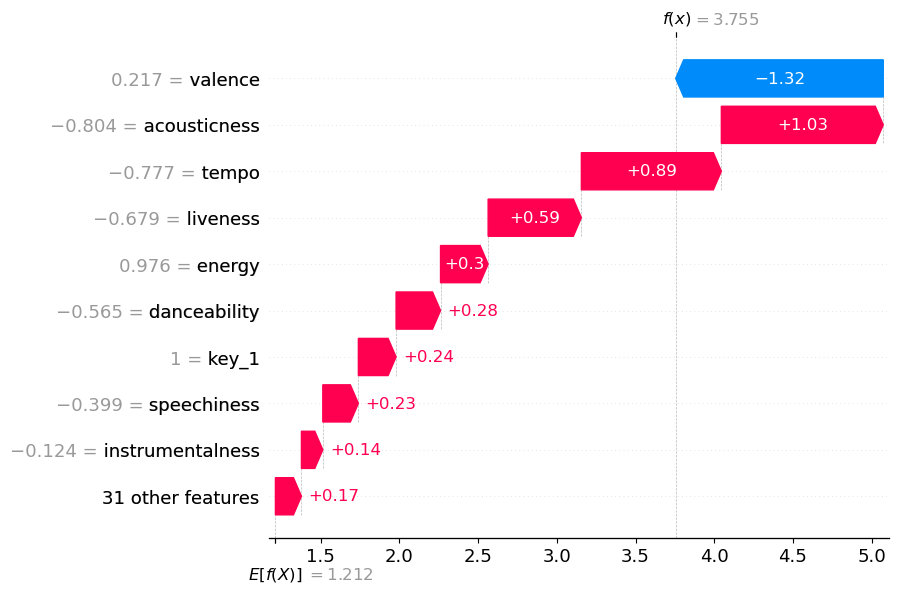

In [18]:
SAMPLE_IDX = 0 # Index of the individual test sample to explain

# Get the model's predicted class for the selected sample
predicted_class = model.predict(X_test[SAMPLE_IDX:SAMPLE_IDX+1])[0]

# Shows each feature's contribution to pushing the prediction above/below the baseline
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_3d[SAMPLE_IDX, :, predicted_class], # SHAP values for this sample's predicted class
        base_values=explainer.expected_value[predicted_class], # Model's default guess, features average

        data=X_test[SAMPLE_IDX], # Raw feature values for the sample
        feature_names=all_features # Feature labels for the x-axis
    )
)
plt.show()

<h3 style="color: grey">Beeswarm Chart</h3>

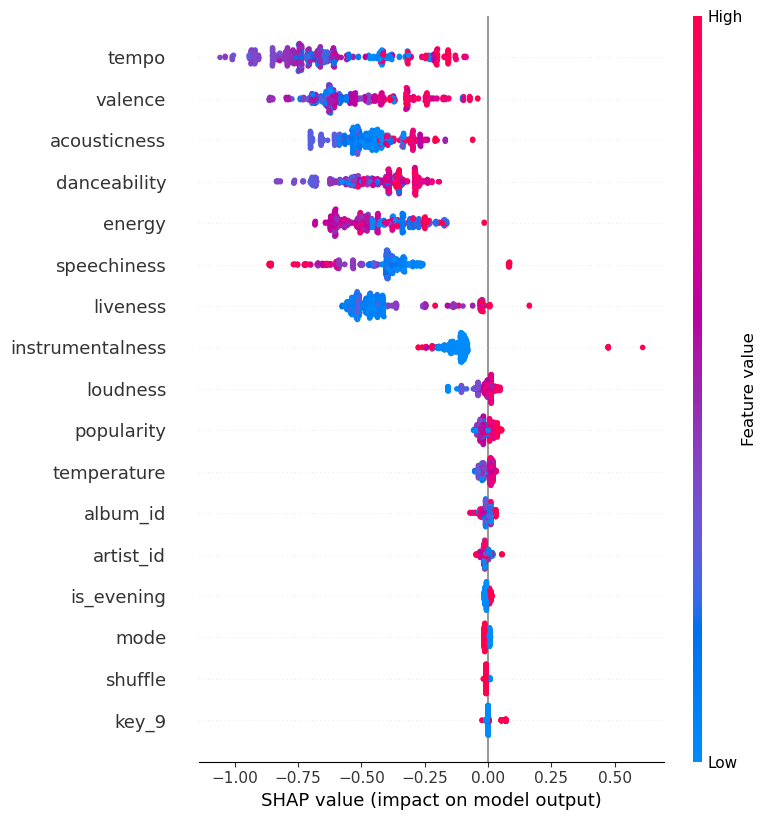

In [19]:
shap.summary_plot(
    shap_values_collapsed,
    X_test[:500],
    feature_names=all_features,
    max_display=17
)

<h3 style="color: grey">Feature Importance Chart</h3>

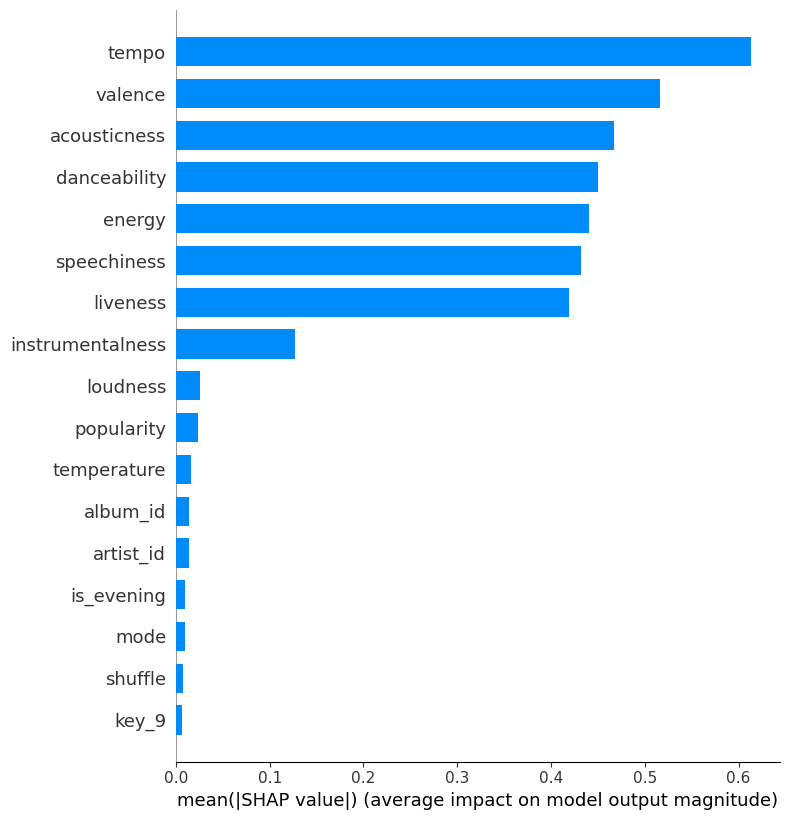

In [20]:
shap.summary_plot(
    shap_values_collapsed,
    X_test[:500],
    feature_names=all_features,
    plot_type='bar',
    max_display=17
)

<h3 style="color: grey">Feature Importance by Cluster Chart</h3>

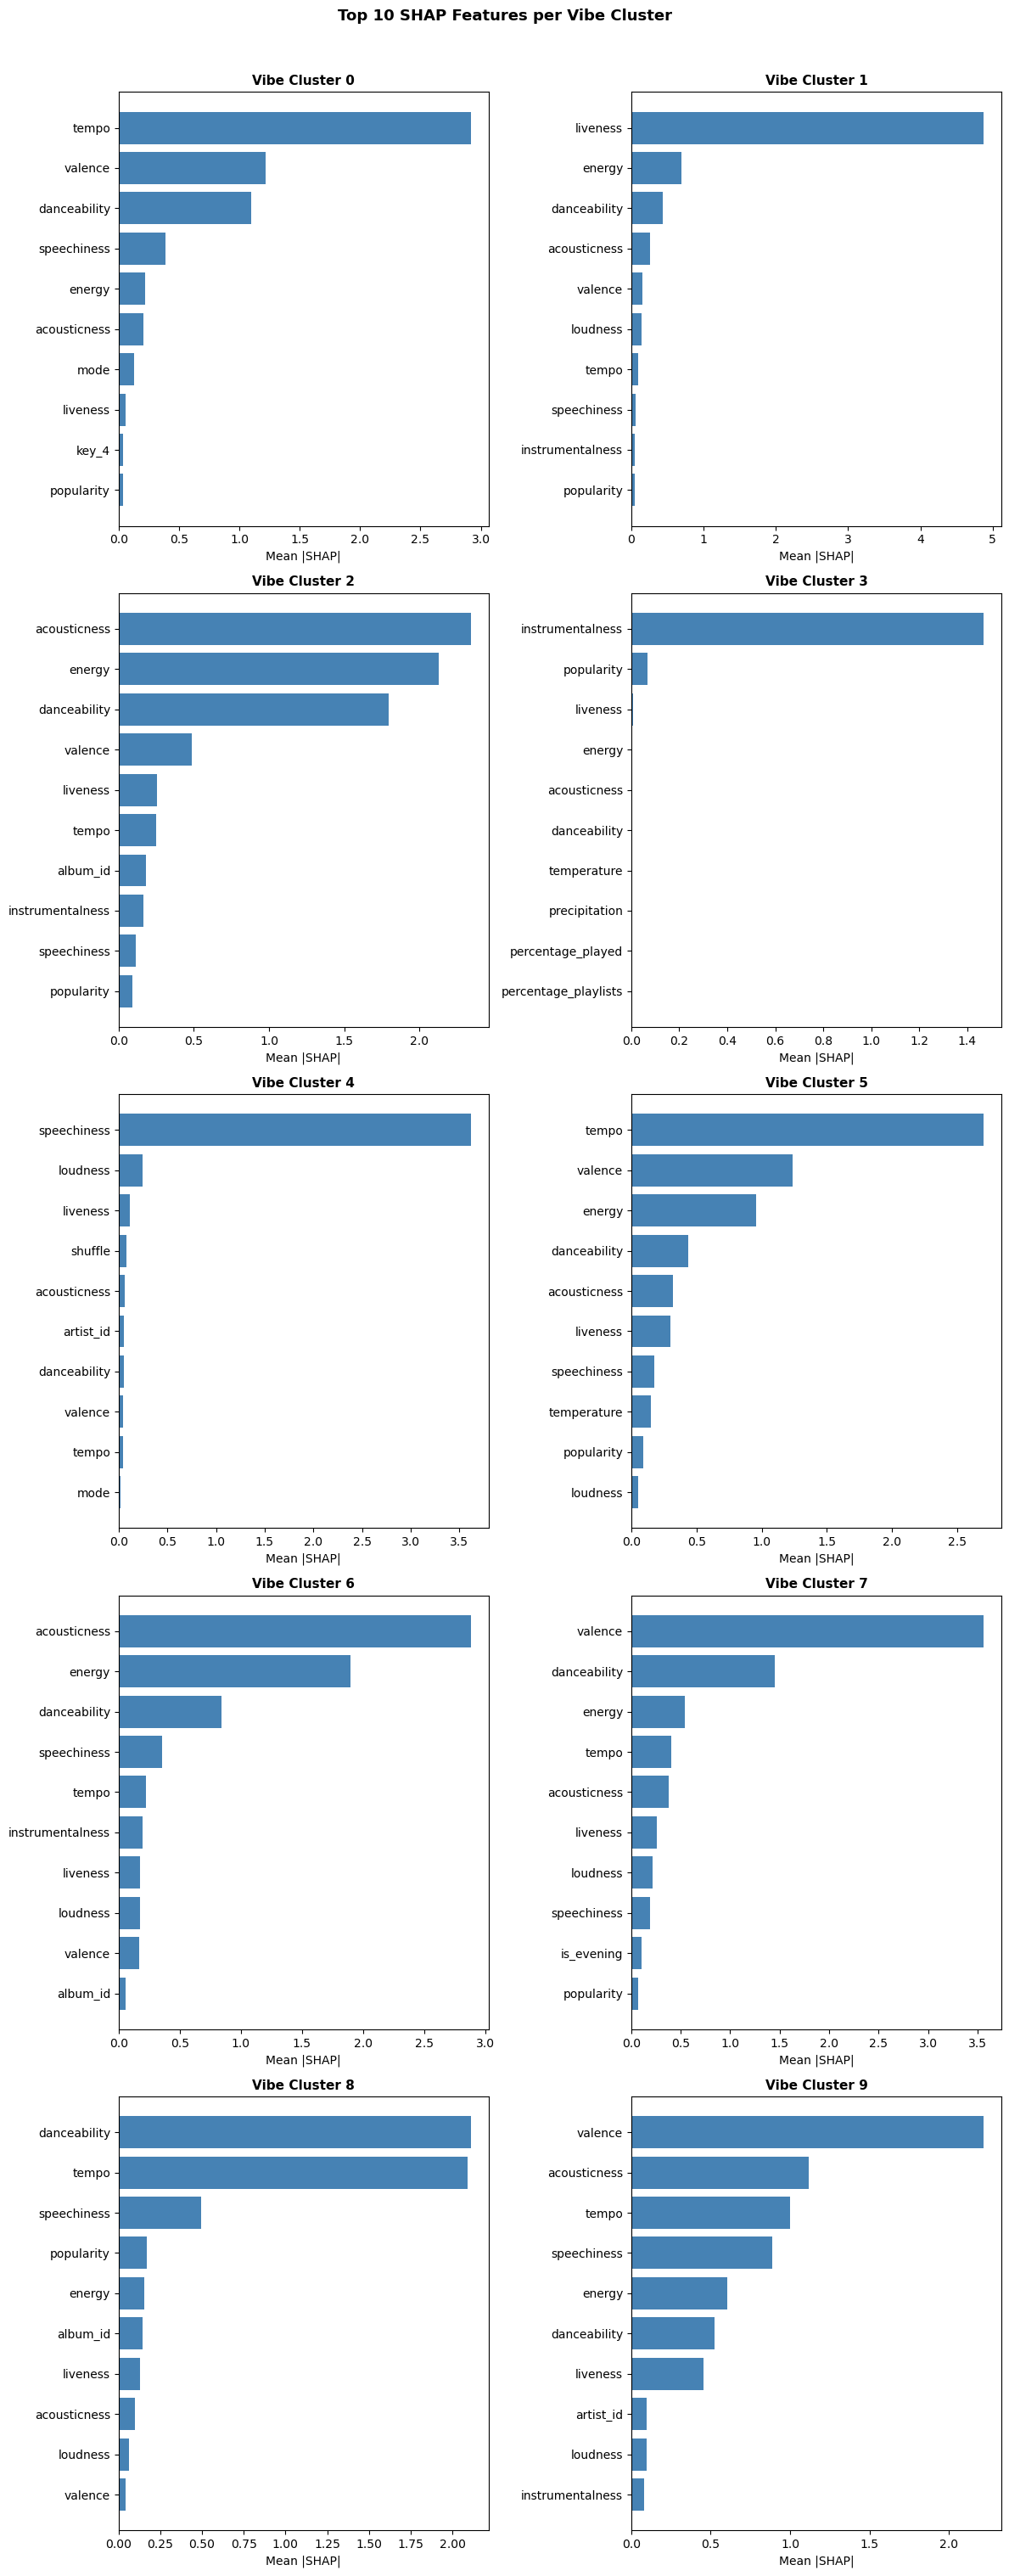

In [21]:
n_clusters = shap_values_3d.shape[2] # Gets the number of clusters

# Creates a grid of subplots, accounting for even and odd clusters amount
fig, axes = plt.subplots((n_clusters + 1) // 2, 2, figsize=(12, n_clusters * 3))

# Iterate over each cluster and its corresponding subplot axis
for cluster_id, ax in enumerate(axes.flatten()[:n_clusters]):

    # Calculates a single "importance score" per feature, by iterating
    mean_abs = np.abs(shap_values_3d[:, :, cluster_id]).mean(axis=0)

    # Get the indices of the top 10 most important features, sorted ascending
    sorted_idx = np.argsort(mean_abs)[-10:]

    # Plot a horizontal bar chart of the top 10 features for this cluster
    ax.barh([all_features[i] for i in sorted_idx], mean_abs[sorted_idx], color='steelblue')
    ax.set_title(f'Vibe Cluster {cluster_id}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')

fig.suptitle('Top 10 SHAP Features per Vibe Cluster', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<h3 style="color: grey">Correlation Analysis Charts</h3>

In [22]:
# Defines reusable function for plotting correlation charts
def plot_corr(df, features, title, filename, figsize):
    # Compute pairwise Pearson correlation coefficients between all selected features
    corr = df[features].corr()

    # Builds an upper-triangle mask ot eliminated mirroing
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        annot=True, # Shows correlation values inside each cell
        fmt='.2f', # Formats values to 2 decimal places
        cmap='coolwarm', # Uses bBlue for negative, red for positive correlations
        center=0, # Anchors the colormap at zero (no correlation)
        vmin=-1, vmax=1, # Fixes scale to full correlation range
        linewidths=0.5, # Adds thin lines between cells for readability
    )

    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

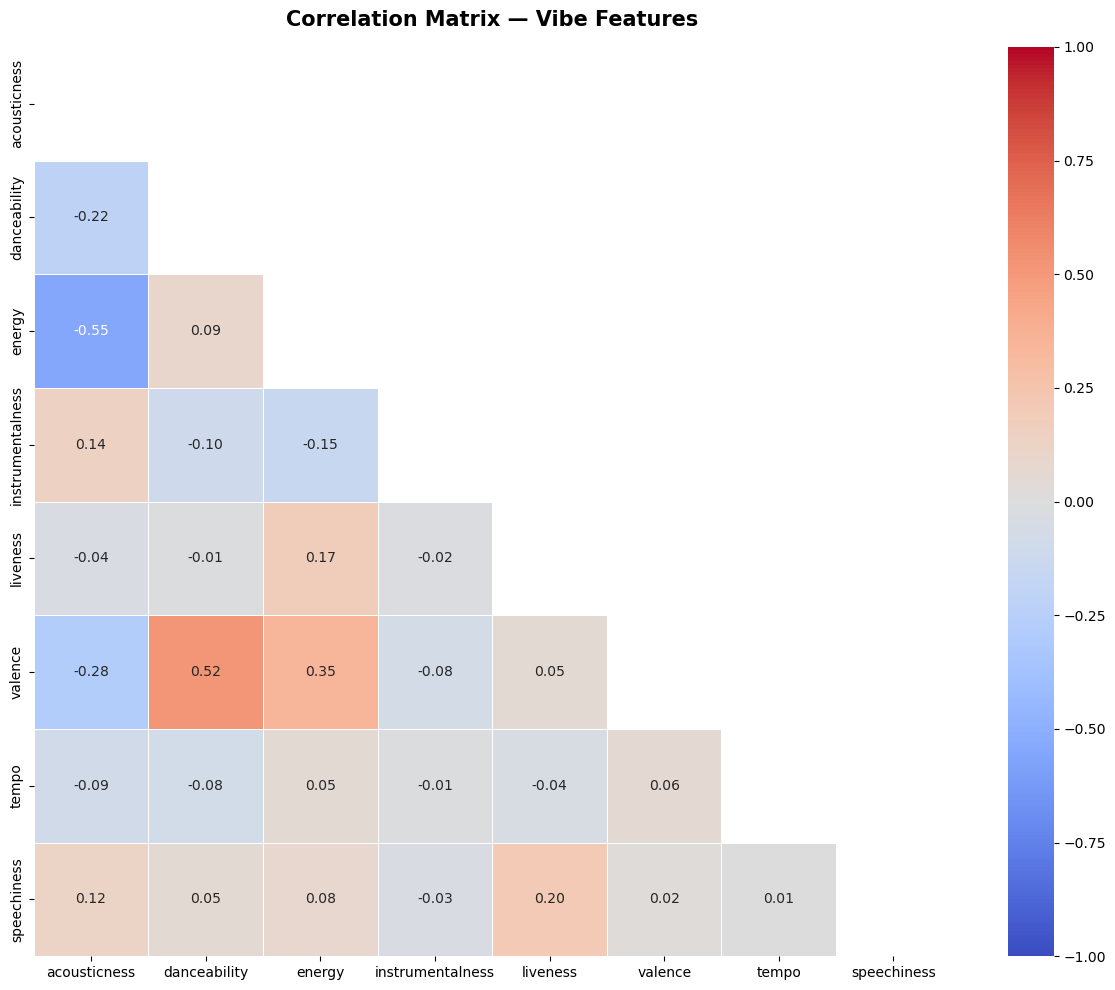

In [23]:
# Plots correlation for the so called vibe features
plot_corr(train_df, vibe_features, 'Correlation Matrix — Vibe Features', 'correlation_matrix_vibe.png', (12, 10))

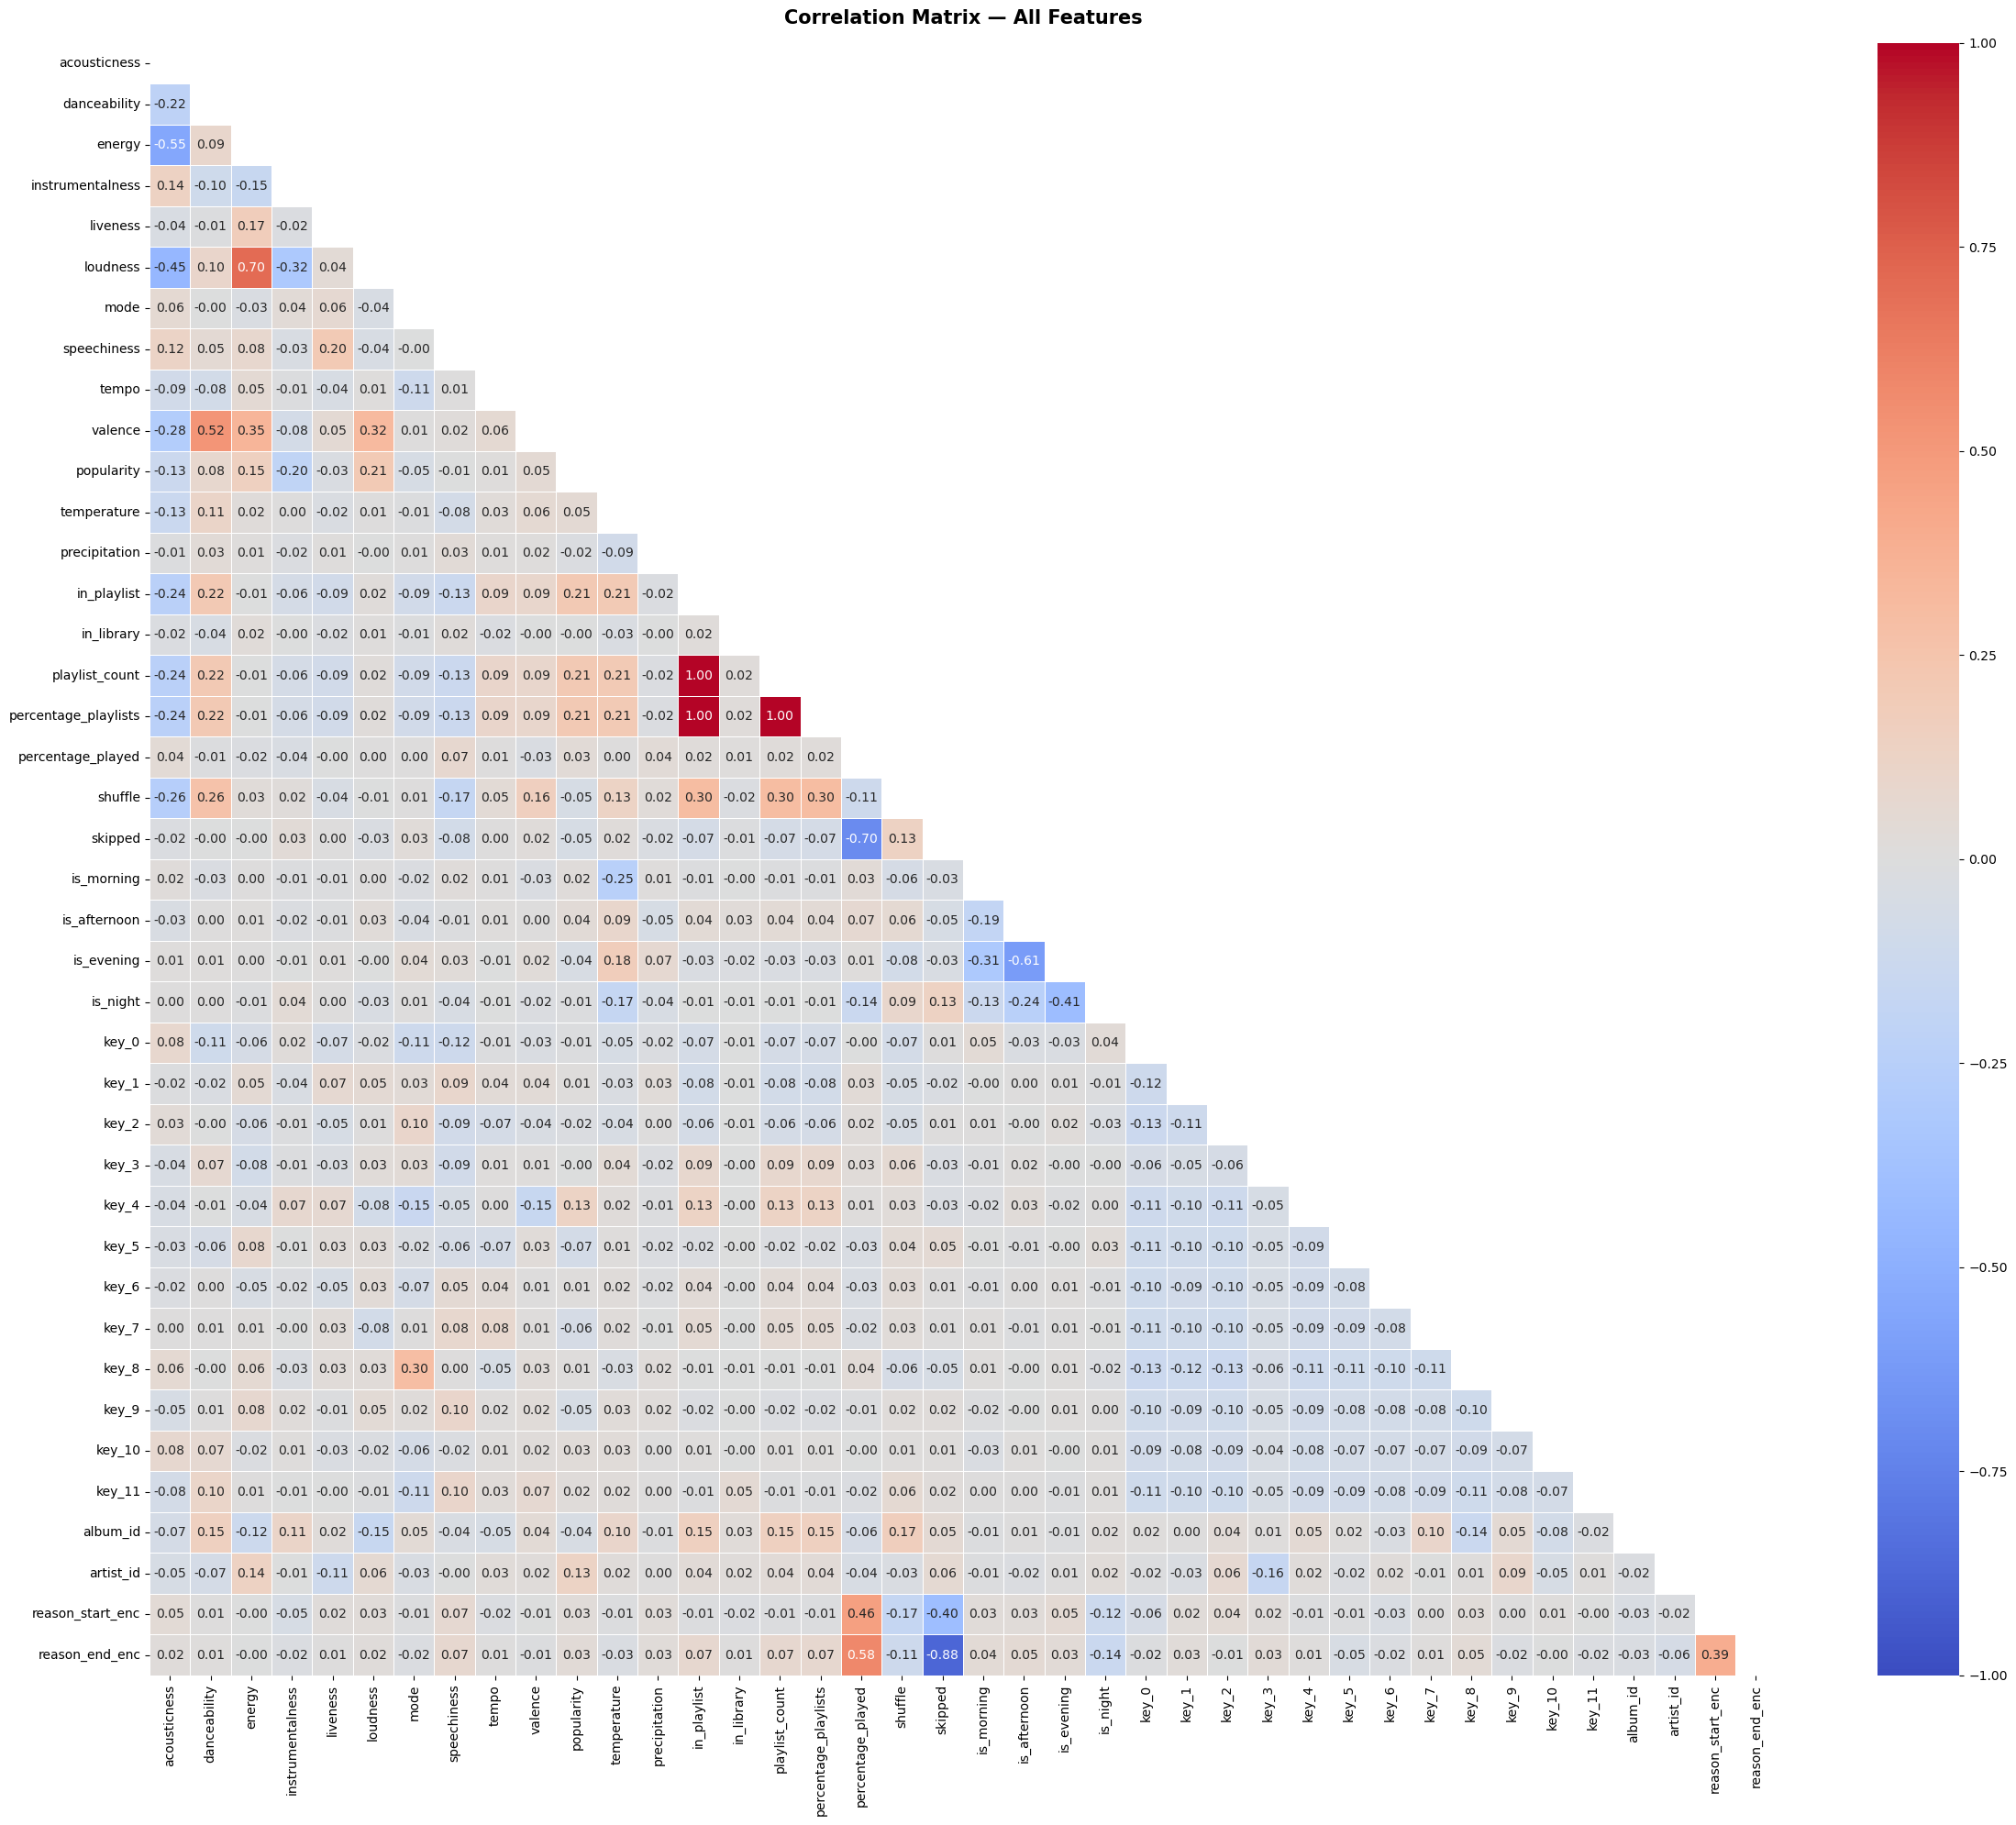

In [25]:
# Plots correlation for all features features
plot_corr(train_df, all_features,  'Correlation Matrix — All Features',  'correlation_matrix_all.png',  (24, 20))

## Model Predictions

<h3 style="color: grey">Function Definition using Model with KNN</h3>

**INFO**: Uses KNN to find the song with the better match inside of the cluster.

In [26]:
def recommend_next_song(current_song_features: dict, df: pd.DataFrame, all_features: list, explainer, n=5, explain=True):
    X_input = pd.DataFrame([current_song_features])[all_features].values

    # Predict vibe cluster
    predicted_proba = model.predict_proba(X_input)[0] # Runs model, and gets clusters probabilities for the first song
    predicted_cluster = np.argmax(predicted_proba) # Gets cluster with the highest match
    print(f'\n🎵 Vibe cluster: {predicted_cluster} | ✅ Match: {round(predicted_proba[predicted_cluster] * 100, 1)}%')

    # SHAP explanation, with the single row
    if explain:
        sv_raw = explainer.shap_values(X_input)
        sv_3d = np.stack(sv_raw, axis=-1) if isinstance(sv_raw, list) else sv_raw # Transform multiple arrays into a single one
        sv_cluster = sv_3d[0, :, predicted_cluster] # Gets cluster predicted

        # Displays the most important features and values, for the precition of this entry
        print('\n🔍 Top features driving this vibe:')
        for feat, val in pd.Series(np.abs(sv_cluster), index=all_features).nlargest(5).items():
            print(f'  {"↑" if sv_cluster[all_features.index(feat)] > 0 else "↓"} {feat}: {val:.4f}')

    # Filters cluster songs, eliminating duplicates and input song
    cluster_songs = (
        df[df['vibe_cluster'] == predicted_cluster]
        .drop_duplicates(subset='track_id')
        .pipe(lambda x: x[x['track_id'] != current_song_features['track_id']] if 'track_id' in current_song_features else x) # Returns only rows where soong is different from input one
        .reset_index(drop=True)
    )

    # Fits a KNN model on the cluster songs using only the vibe features, and works if there are less entries than requested
    knn = NearestNeighbors(n_neighbors=min(n, len(cluster_songs)), metric='euclidean').fit(cluster_songs[vibe_features])

    # Finds the five neirghest songs from the DataFrame
    distances, indices = knn.kneighbors([[current_song_features[f] for f in vibe_features]])

    # Uses the returned indices to pull the actual songs from cluster_songs
    recs = cluster_songs.iloc[indices[0]][['track_id'] + vibe_features].copy()

    # Attaches the euclidean distance so we know how close each recommendation is to the input song
    recs['distance'] = distances[0]

    # Print full results without truncation
    print(f'\n🎶 Top {n} closest tracks in cluster:')
    print(recs[['track_id', 'distance']])

    return recs

<h3 style="color: grey">Function Call and Avaliation</h3>

In [28]:
# Picks a random song from the test set as the "currently playing" song
sample = test_split_df.sample(1).iloc[0]
sample_features = {feat: sample[feat] for feat in all_features}

print(f'▶️  Currently playing: {sample["track_id"]}')

# Uses function to retrieve the closest matching songs
recs = recommend_next_song(sample_features, train_split_df, all_features=all_features, explainer=explainer, n=5, explain=True)

# Displays the recommended songs in order
print('\n🎵 Recommended tracks:')
for i, track_id in enumerate(recs['track_id'].tolist(), 1):
    print(f'  {i}. {track_id}')

▶️  Currently playing: 11ZulcYY4lowvcQm4oe3VJ

🎵 Vibe cluster: 2 | ✅ Match: 98.5%

🔍 Top features driving this vibe:
  ↓ acousticness: 2.5731
  ↑ energy: 2.5610
  ↑ danceability: 2.2170
  ↑ valence: 0.6518
  ↓ instrumentalness: 0.4621

🎶 Top 5 closest tracks in cluster:
                  track_id  distance
8   7g7w2WUpLcqsqH2M9XR7ZF  0.644483
85  5hqK5evNmuLtIiQs4Z5N1M  1.332269
42  3I3u1ToIan8l0FKA7wV1QO  1.659513
54  4qbEaaJ29p32GI8EWQmm6R  1.692917
6   6i0V12jOa3mr6uu4WYhUBr  1.707857

🎵 Recommended tracks:
  1. 7g7w2WUpLcqsqH2M9XR7ZF
  2. 5hqK5evNmuLtIiQs4Z5N1M
  3. 3I3u1ToIan8l0FKA7wV1QO
  4. 4qbEaaJ29p32GI8EWQmm6R
  5. 6i0V12jOa3mr6uu4WYhUBr
